# GN/EGN modulation code — attached paper Fig. 1–3 validation

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/2026_KICS_Fall_10/GN_modulation_Fig123_validation_colab.ipynb)

This notebook compares the general GN engine and modulation/performance layer against the three plots in **A Simple and Accurate Closed-Form EGN Model Formula**. The paper curves were read directly from the supplied PDF vector artwork; they are reference points with approximately 0.1 dB / 0.1-span plot-reading precision, not fitted data.

**No fitting is used.** All parameters, launch-power grids, Sobol powers, receiver quadrature orders, and seeds are fixed before the comparison. Fig. 3 reports the mean and standard deviation of three independent scrambled-Sobol seeds so that numerical variation is visible.

The engine default is pure GN. Its optional egn_sci path is restricted to rectangular spectra and SCI; the paper figures use roll-off 0.05 and full WDM EGN/SIM, so those curves are shown as external references, not silently claimed as reproduced by the present engine. XCI/MCI EGN corrections and SSFM are not implemented here.

In [ ]:
# Colab/local path setup. When opened from GitHub, this finds the sibling modules
# and JSON caches; if they are absent, it downloads the exact tracked files.
from pathlib import Path
import sys, json, urllib.request

REPO = "https://raw.githubusercontent.com/kimheeseo/LSCNS/main/2026_KICS_Fall_10/"
candidates = [Path.cwd(), Path("/content/LSCNS/2026_KICS_Fall_10"),
              Path("/content/2026_KICS_Fall_10")]
BASE = next((p for p in candidates if (p / "gn_integral_general.py").exists()), candidates[0])
BASE.mkdir(parents=True, exist_ok=True)
needed = ["gn_integral_general.py", "gn_integral_general_modulation.py",
          "paper_fig12_reference.json", "paper_fig3_reference.json",
          "fig12_results_avg.json", "fig3_code_gn_seeds.json"]
for name in needed:
    path = BASE / name
    if not path.exists():
        urllib.request.urlretrieve(REPO + name, path)
sys.path.insert(0, str(BASE))
print("Using", BASE)

In [ ]:
import math, json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from gn_integral_general import WDMSystem, Span, GNIntegralOptions, integrate_nli_over_channel
from gn_integral_general_modulation import (
    evaluate_performance, launch_power_vs_gsnr, get_modulation,
    constellation_moment_self_test,
)
print(constellation_moment_self_test())
print("QPSK moments:", get_modulation("QPSK").mu4, get_modulation("QPSK").mu6)

## 1. Paper conditions and reference extraction

| Plot | System | Fiber / span | Launch and receiver |
|---|---|---|---|
| Fig. 1 | 3 PM-QPSK, 32 GBd, spacing 33.6 GHz, RC roll-off 0.05 | 100 km; SMF/NZDSF/LS, alpha=0.22 dB/km | −3 dBm/channel; noiseless NLI coefficient |
| Fig. 2 | 15 PM-QPSK, otherwise same | 100 km; SMF/NZDSF/LS, alpha=0.22 dB/km | −3 dBm/channel; noiseless NLI coefficient |
| Fig. 3 | 15 channels, 32 GBd, RC/RRC roll-off 0.05; Δf=33.6/35/40/45/50 GHz | PM-QPSK: 120 km; PM-16QAM: 85 km; NF=5 dB; PSCF/SMF/NZDSF/LS | BER targets 1.7×10⁻³ (QPSK), 2×10⁻³ (16QAM) |

The paper's Fig. 1–2 quantity is eta_NLI=P_NLI/P_ch³, plotted as 10 log10(eta_NLI) in dB referred to 1 W⁻². Reference arrays are in paper_fig12_reference.json and paper_fig3_reference.json; metadata records PDF page and vector-axis extraction. Supplied PDF SHA-256: e90abf9a9927cf82e7578b4e74f9b1d06a2956d0911c505921ceabe74a3ba40f.

In [ ]:
paper12 = json.loads((BASE / "paper_fig12_reference.json").read_text())
paper3 = json.loads((BASE / "paper_fig3_reference.json").read_text())
cached12 = json.loads((BASE / "fig12_results_avg.json").read_text())
cached3 = json.loads((BASE / "fig3_code_gn_seeds.json").read_text())
NSPAN = paper12["nspan"]
SPACING = paper3["channel_spacing_GHz"]
print("Fig. 1/2 reference points:", len(cached12), "Fig. 3 points:", len(cached3))

## 2. Fig. 1–2 reproduction through the modulation layer

The next cell calls evaluate_performance with modulation="QPSK" and nli_model="gn"; the returned p_nli_W is converted to eta_NLI. In GN mode QPSK metadata is intentionally not used as an NLI correction, matching the paper GN reference and preserving the pure-GN default. Set RUN_FIG12=True to recompute instead of using the checked-in cache (36 integrals, three seeds, Sobol 2¹⁶ points).

In [ ]:
RUN_FIG12 = False
FIG12_SEEDS = (11, 22, 33)
FIG12_SOBOL_POWER = 16
FIG12_RECEIVER_POINTS = 7
FIBERS12 = {"SMF": (16.7, 1.3, 0.22), "NZDSF": (3.8, 1.5, 0.22),
            "LS": (-1.8, 2.2, 0.22)}

def run_fig12():
    rows = []
    for fig_name, nch in (("Fig1", 3), ("Fig2", 15)):
        for fiber, (D, gamma, alpha) in FIBERS12.items():
            for nspan in NSPAN:
                system = WDMSystem.equispaced(nch, 33.6, 32.0, -3.0,
                    pulse_shape="raised_cosine", rolloff=0.05)
                spans = [Span(100.0, alpha, gamma, D_ps_nm_km=D,
                              wavelength_nm=1550.0) for _ in range(nspan)]
                vals = []
                for seed in FIG12_SEEDS:
                    opt = GNIntegralOptions(sobol_power=FIG12_SOBOL_POWER, seed=seed)
                    result = evaluate_performance(system, spans, nch // 2,
                        modulation="QPSK", gn_options=opt,
                        receiver_points=FIG12_RECEIVER_POINTS, nli_model="gn")
                    pch = system.channels[nch // 2].power_W
                    vals.append(10.0 * np.log10(result.p_nli_W / pch**3))
                rows.append({"fig": fig_name, "nch": nch, "fiber": fiber,
                    "nspan": nspan, "eta_db_mean": float(np.mean(vals)),
                    "eta_db_std": float(np.std(vals, ddof=1)),
                    "eta_db_values": [float(v) for v in vals]})
    return rows

code12 = run_fig12() if RUN_FIG12 else cached12

In [ ]:
def make_fig12_tables(code_rows):
    rows = []
    for r in code_rows:
        ref = paper12["curves"][f"{r['fig']}-{r['fiber']}"]["GN"][NSPAN.index(r["nspan"])]
        delta = r["eta_db_mean"] - ref
        rows.append({"Fig": r["fig"], "Nch": r["nch"], "Fiber": r["fiber"],
            "Nspan": r["nspan"], "Paper GN [dB]": ref, "Code GN [dB]": r["eta_db_mean"],
            "Abs error [dB]": abs(delta),
            "Relative error [%]": abs(10**(delta/10.0)-1.0)*100.0,
            "QMC std [dB]": r["eta_db_std"]})
    detail = pd.DataFrame(rows)
    summary = detail.groupby(["Fig", "Fiber"], as_index=False).agg(
        points=("Nspan", "size"), mean_abs_error_db=("Abs error [dB]", "mean"),
        max_abs_error_db=("Abs error [dB]", "max"),
        mean_relative_error_pct=("Relative error [%]", "mean"),
        max_relative_error_pct=("Relative error [%]", "max"),
        mean_qmc_std_db=("QMC std [dB]", "mean"),
        max_qmc_std_db=("QMC std [dB]", "max"))
    return detail, summary

detail12, summary12 = make_fig12_tables(code12)
display(summary12.round(4))
display(detail12.round(4))
print("Overall mean abs dB:", detail12["Abs error [dB]"].mean())
print("Overall max abs dB:", detail12["Abs error [dB]"].max())
print("Overall mean relative %:", detail12["Relative error [%]"].mean())

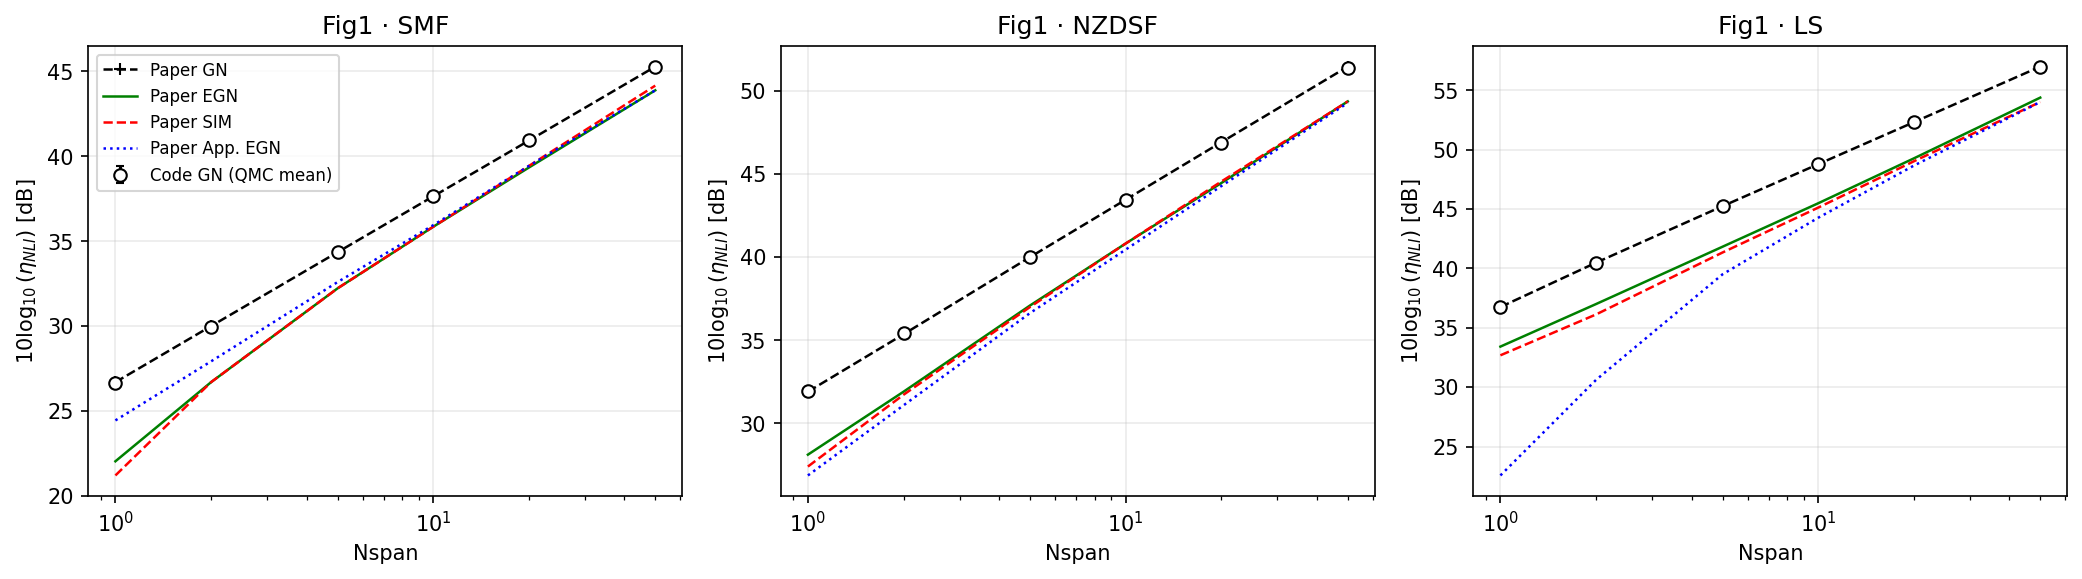

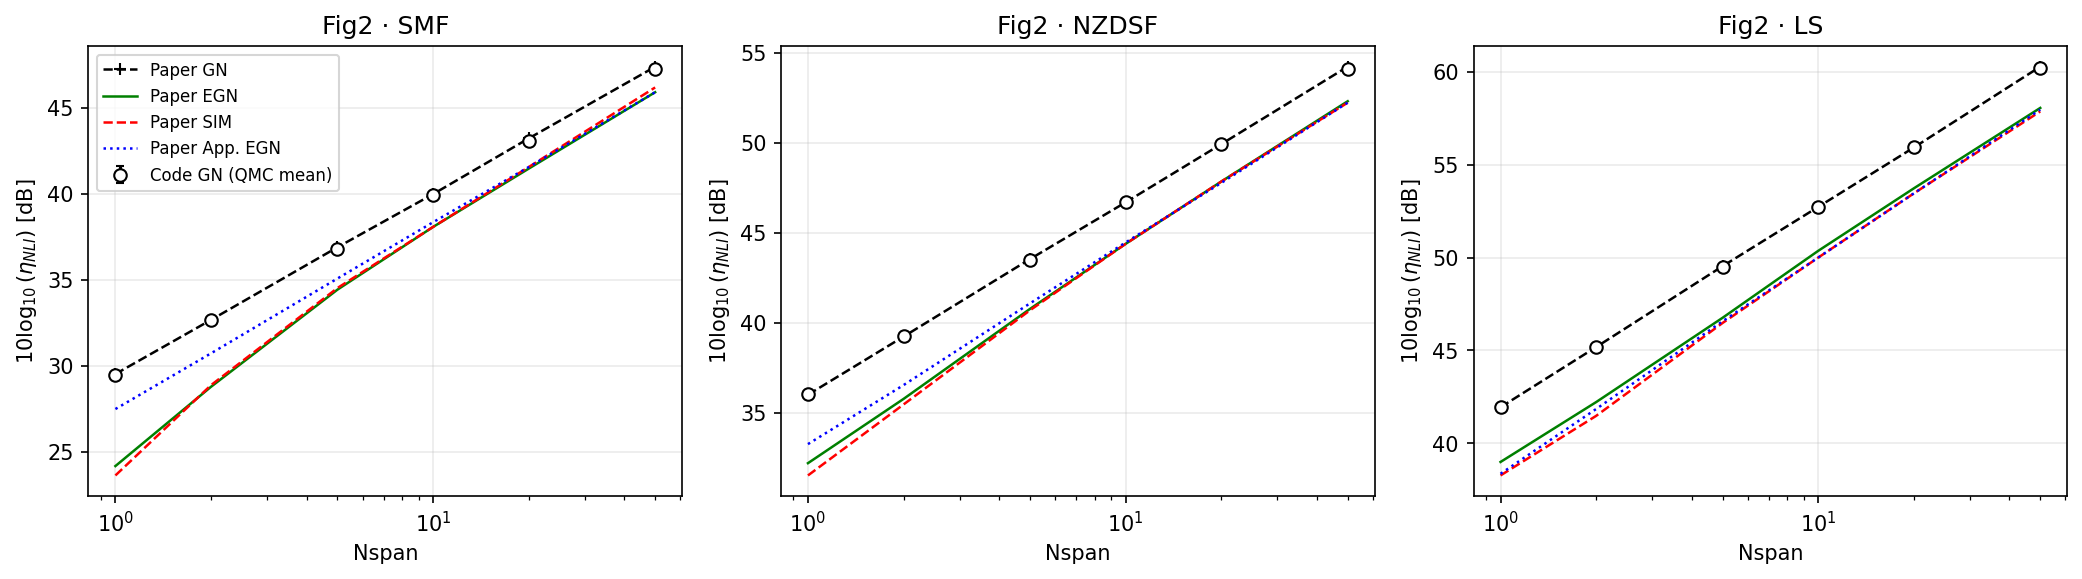

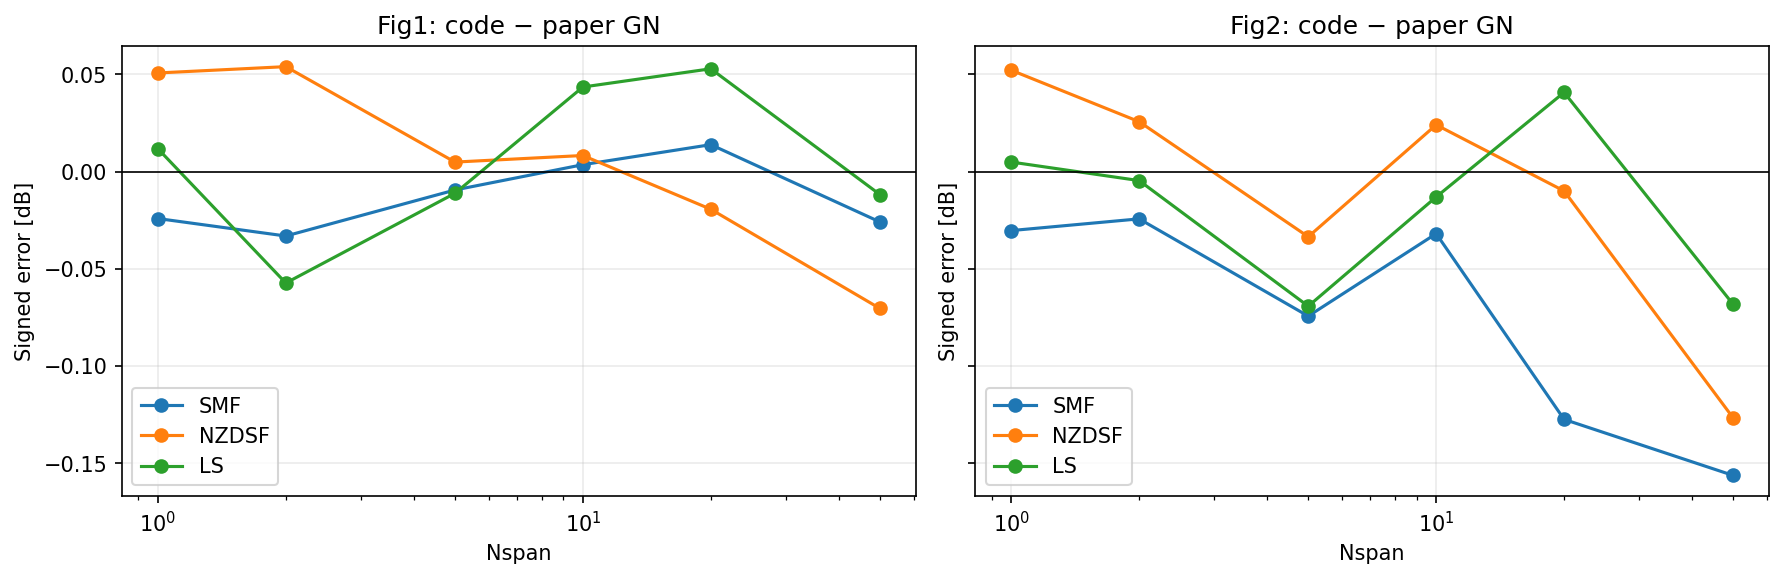

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
for ax, fiber in zip(axes, ("SMF", "NZDSF", "LS")):
    curves = paper12["curves"][f"Fig1-{fiber}"]
    ax.plot(NSPAN, curves["GN"], "k+--", label="Paper GN")
    ax.plot(NSPAN, curves["EGN"], "g-", label="Paper EGN")
    ax.plot(NSPAN, curves["SIM"], "r--", label="Paper SIM")
    ax.plot(NSPAN, curves["App_EGN"], "b:", label="Paper App. EGN")
    sub = detail12[(detail12.Fig == "Fig1") & (detail12.Fiber == fiber)]
    ax.errorbar(NSPAN, sub["Code GN [dB]"], yerr=sub["QMC std [dB]"],
                fmt="ko", mfc="white", capsize=2, label="Code GN")
    ax.set_xscale("log"); ax.set_title(f"Fig. 1 · {fiber}")
    ax.set_xlabel("Nspan"); ax.set_ylabel("eta_NLI [dB]"); ax.grid(alpha=.25)
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
for ax, fiber in zip(axes, ("SMF", "NZDSF", "LS")):
    curves = paper12["curves"][f"Fig2-{fiber}"]
    ax.plot(NSPAN, curves["GN"], "k+--", label="Paper GN")
    ax.plot(NSPAN, curves["EGN"], "g-", label="Paper EGN")
    ax.plot(NSPAN, curves["SIM"], "r--", label="Paper SIM")
    ax.plot(NSPAN, curves["App_EGN"], "b:", label="Paper App. EGN")
    sub = detail12[(detail12.Fig == "Fig2") & (detail12.Fiber == fiber)]
    ax.errorbar(NSPAN, sub["Code GN [dB]"], yerr=sub["QMC std [dB]"],
                fmt="ko", mfc="white", capsize=2, label="Code GN")
    ax.set_xscale("log"); ax.set_title(f"Fig. 2 · {fiber}")
    ax.set_xlabel("Nspan"); ax.set_ylabel("eta_NLI [dB]"); ax.grid(alpha=.25)
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, fig_name in zip(axes, ("Fig1", "Fig2")):
    for fiber in ("SMF", "NZDSF", "LS"):
        sub = detail12[(detail12.Fig == fig_name) & (detail12.Fiber == fiber)]
        ax.plot(sub["Nspan"], sub["Code GN [dB]"] - sub["Paper GN [dB]"], "o-", label=fiber)
    ax.axhline(0, color="k", lw=.8); ax.set_xscale("log")
    ax.set_title(f"{fig_name}: code − paper GN [dB]")
    ax.set_xlabel("Nspan"); ax.set_ylabel("Signed error [dB]"); ax.grid(alpha=.25); ax.legend()
plt.tight_layout(); plt.show()

**Fig. 1–2 interpretation.** The cached three-seed run has mean absolute error about 0.04 dB and maximum about 0.16 dB against the digitized paper GN curve. The paper EGN/SIM curves are deliberately left on the plot; the present engine does not claim to reproduce them for RC roll-off 0.05 because its EGN option is SCI-only/rectangular-spectrum. The small error bars are QMC seed variation, not a fitted uncertainty band.

## 3. Fig. 3 maximum-reach comparison

launch_power_vs_gsnr is called with a fixed launch-power grid −10 to +5 dBm in 0.25 dB steps. For each integer span count, the best GSNR on that grid is tested against the paper BER threshold; binary search returns the largest passing integer span. No curve fitting or parameter tuning is performed. Three Sobol seeds (11, 22, 33) are run independently and reported as mean ± sample standard deviation.

The paper curve is continuous-looking and was digitized from a log-span axis, while this implementation reports integer pass/fail reaches. This quantization and the QMC seed spread are included in the error columns. Comparison with SIM is diagnostic only: this code is a GN model and has no SSFM simulator.

In [ ]:
RUN_FULL_FIG3 = False
FIG3_SEEDS = (11, 22, 33)
PGRID = np.arange(-10.0, 5.001, 0.25)
FIG3_OPT = dict(sobol_power=16, receiver_points=5)
FIBERS3 = {"PSCF": (20.1, 0.8, 0.17), "SMF": (16.7, 1.3, 0.20),
           "NZDSF": (3.8, 1.5, 0.22), "LS": (-1.8, 2.2, 0.22)}
MODS3 = {"QPSK": (120.0, 1.7e-3), "16QAM": (85.0, 2.0e-3)}

def _fig3_at_nspan(modulation, spacing, fiber, nspan, seed):
    length, target_ber = MODS3[modulation]
    D, gamma, alpha = FIBERS3[fiber]
    system = WDMSystem.equispaced(15, spacing, 32.0, -3.0,
        pulse_shape="raised_cosine", rolloff=0.05)
    spans = [Span(length, alpha, gamma, D_ps_nm_km=D, wavelength_nm=1550.0,
                  noise_figure_db=5.0) for _ in range(nspan)]
    out = launch_power_vs_gsnr(system, spans, 7, PGRID, modulation=modulation,
        gn_options=GNIntegralOptions(sobol_power=FIG3_OPT["sobol_power"], seed=seed),
        receiver_points=FIG3_OPT["receiver_points"], nli_model="gn")
    best = int(np.argmax(out["gsnr_db"]))
    return {"pass": bool(np.min(out["ber"]) <= target_ber),
            "best_ber": float(np.min(out["ber"])),
            "best_gsnr_db": float(out["gsnr_db"][best]),
            "best_power_dBm": float(out["launch_power_dBm"][best]),
            "nspan": int(nspan)}

def _fig3_max_reach(modulation, spacing, fiber, seed):
    cache = {}
    def ev(n):
        n = int(n)
        if n not in cache: cache[n] = _fig3_at_nspan(modulation, spacing, fiber, n, seed)
        return cache[n]
    lo, hi = 0, 1
    while ev(hi)["pass"] and hi < 256:
        lo, hi = hi, hi * 2
    while hi - lo > 1:
        mid = (lo + hi) // 2
        if ev(mid)["pass"]: lo = mid
        else: hi = mid
    return ev(lo)

def run_fig3_seed(seed):
    rows = []
    for modulation in MODS3:
        for fiber in FIBERS3:
            for spacing in SPACING:
                rows.append({"modulation": modulation, "fiber": fiber,
                    "spacing_GHz": spacing,
                    **_fig3_max_reach(modulation, spacing, fiber, seed)})
    return rows

# Checked-in cache is from exactly the above procedure for seeds 11/22/33.
# Set RUN_FULL_FIG3=True to recompute; it may take several minutes in Colab.
def run_fig3():
    runs = [run_fig3_seed(seed) for seed in FIG3_SEEDS]
    aggregate = []
    for i, base in enumerate(runs[0]):
        values = [x["nspan"] for x in (run[i] for run in runs)]
        aggregate.append({"modulation": base["modulation"], "fiber": base["fiber"],
            "spacing_GHz": base["spacing_GHz"], "nspan_mean": float(np.mean(values)),
            "nspan_std": float(np.std(values, ddof=1)), "nspan_values": values})
    return aggregate

code3 = run_fig3() if RUN_FULL_FIG3 else cached3

In [ ]:
rows = []
for r in code3:
    j = SPACING.index(r["spacing_GHz"])
    ref_gn = paper3["curves"][r["modulation"]][r["fiber"]]["GN"][j]
    ref_sim = paper3["curves"][r["modulation"]][r["fiber"]]["SIM"][j]
    delta = r["nspan_mean"] - ref_gn
    rows.append({"Modulation": r["modulation"], "Fiber": r["fiber"],
        "Spacing [GHz]": r["spacing_GHz"], "Paper GN [span]": ref_gn,
        "Paper SIM [span]": ref_sim, "Code GN mean [span]": r["nspan_mean"],
        "Code seed std [span]": r["nspan_std"],
        "Abs error vs GN [span]": abs(delta),
        "Relative error vs GN [%]": abs(delta) / ref_gn * 100.0,
        "Gap code − SIM [span]": r["nspan_mean"] - ref_sim,
        "Seed reaches": ", ".join(map(str, r["nspan_values"]))})
detail3 = pd.DataFrame(rows)
summary3 = detail3.groupby("Modulation", as_index=False).agg(
    points=("Spacing [GHz]", "size"), mean_abs_error_span=("Abs error vs GN [span]", "mean"),
    max_abs_error_span=("Abs error vs GN [span]", "max"),
    mean_relative_error_pct=("Relative error vs GN [%]", "mean"),
    max_relative_error_pct=("Relative error vs GN [%]", "max"),
    max_seed_std_span=("Code seed std [span]", "max"))
sim = (detail3.assign(abs_sim=lambda x: abs(x["Gap code − SIM [span]"]) /
                      x["Paper SIM [span]"] * 100.0)
       .groupby("Modulation", as_index=False)
       .agg(mean_relative_error_vs_sim_pct=("abs_sim", "mean"),
            max_relative_error_vs_sim_pct=("abs_sim", "max")))
summary3 = summary3.merge(sim, on="Modulation")
display(summary3.round(4)); display(detail3.round(4))

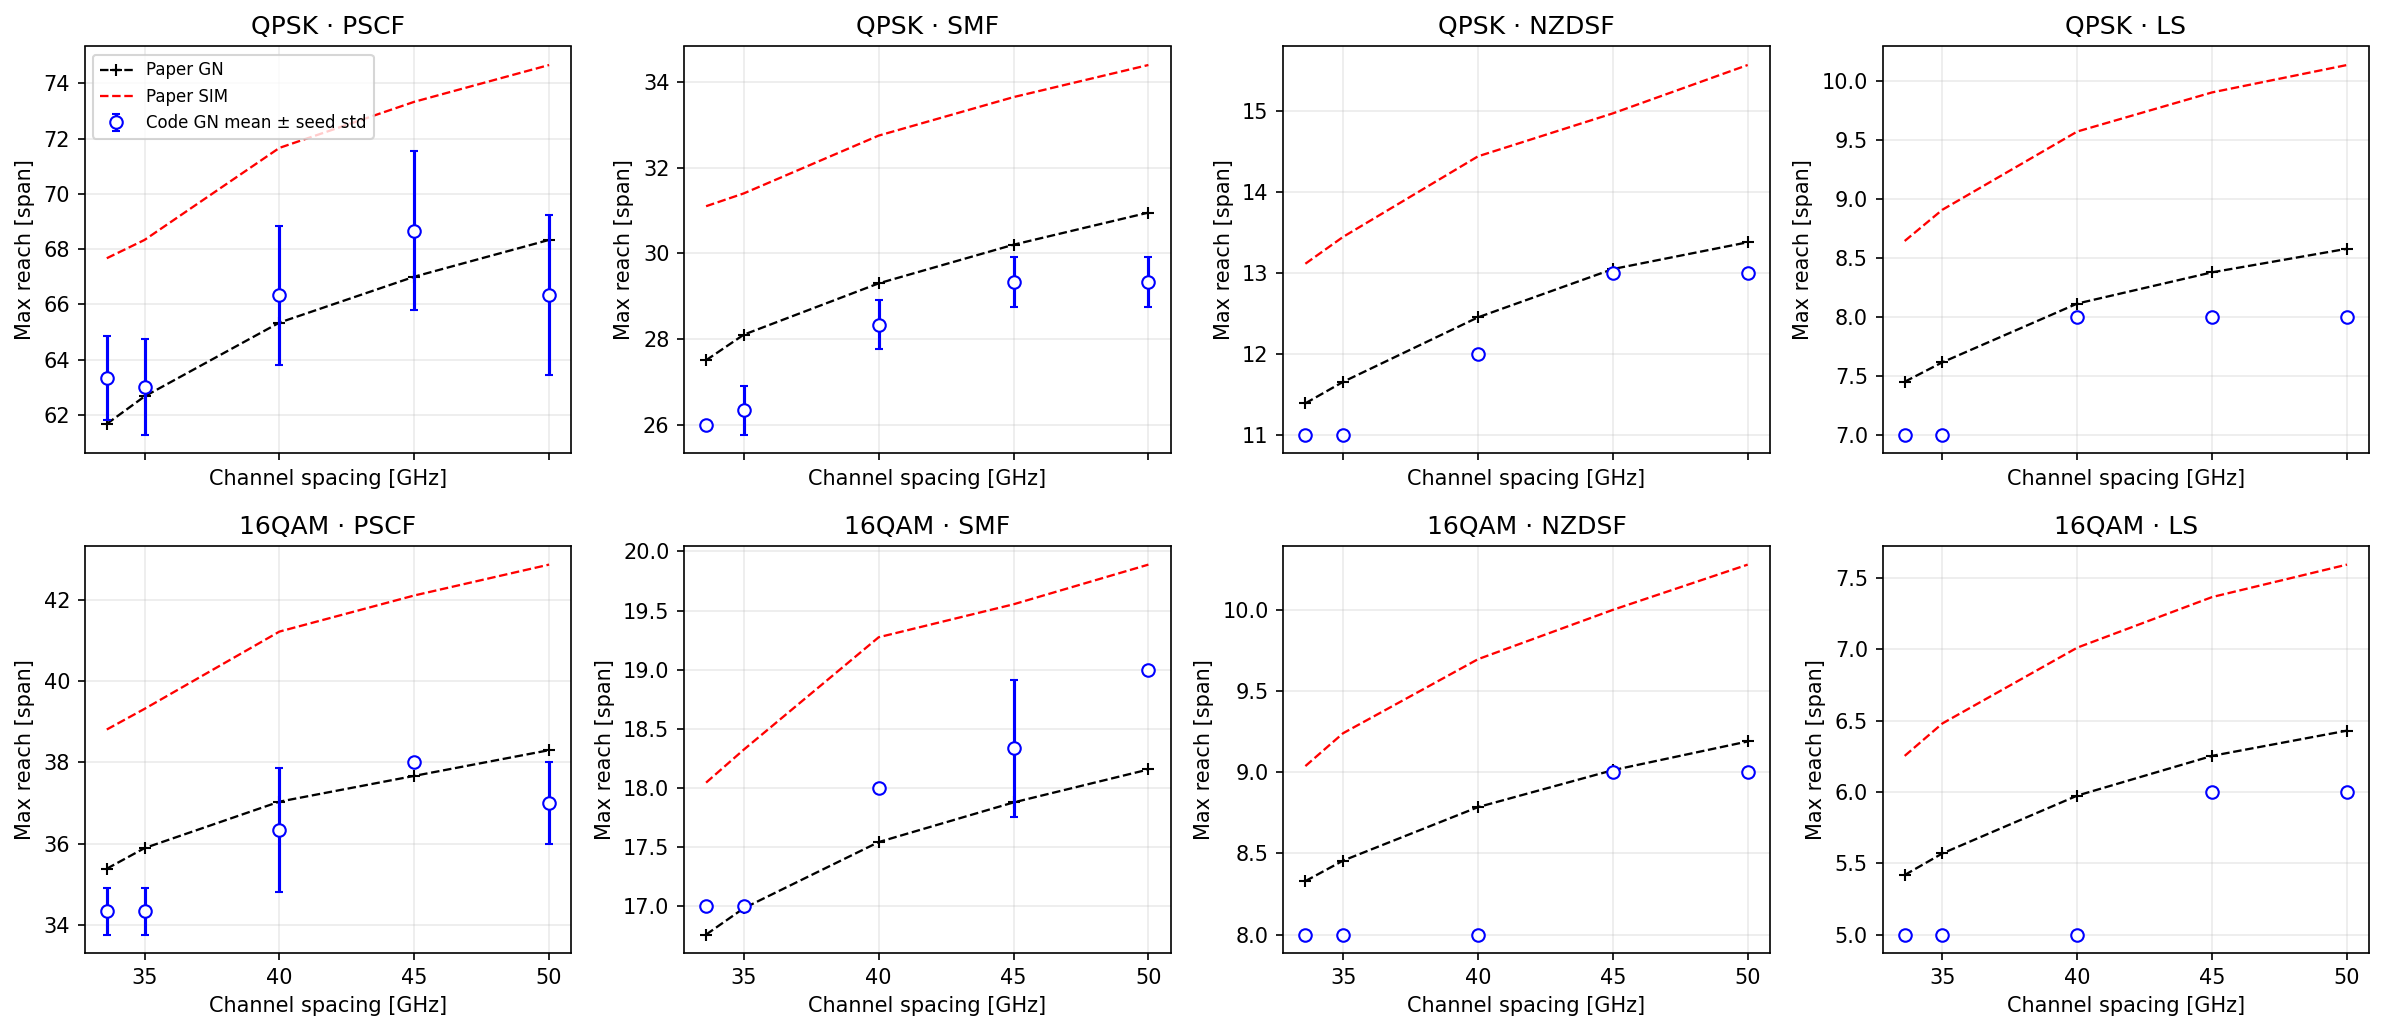

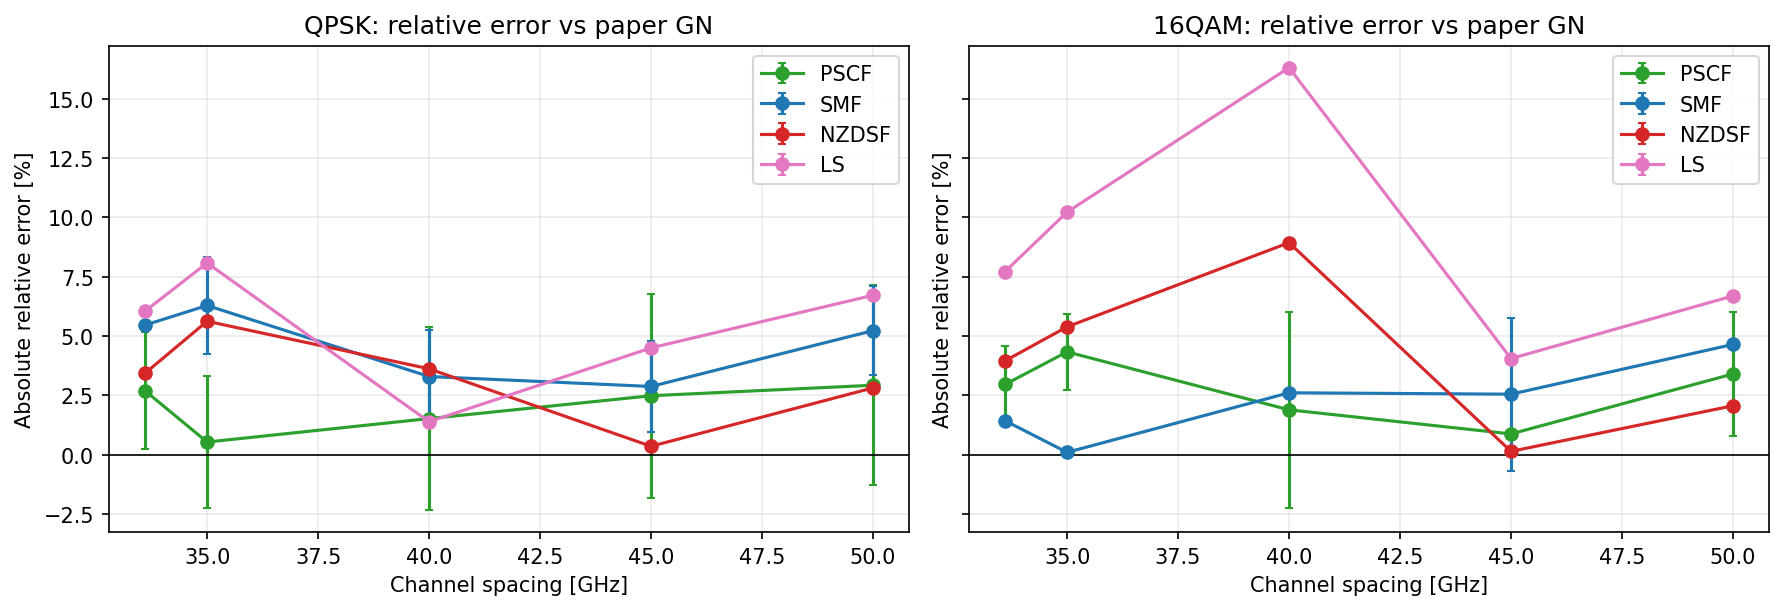

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
for ax, (mod, fiber) in zip(axes.ravel(),
    [(m, f) for m in ("QPSK", "16QAM") for f in ("PSCF", "SMF", "NZDSF", "LS")]):
    curves = paper3["curves"][mod][fiber]
    sub = detail3[(detail3.Modulation == mod) & (detail3.Fiber == fiber)]
    ax.plot(SPACING, curves["GN"], "k+--", label="Paper GN")
    ax.plot(SPACING, curves["SIM"], "r--", label="Paper SIM")
    ax.errorbar(SPACING, sub["Code GN mean [span]"], yerr=sub["Code seed std [span]"],
                fmt="bo", mfc="white", capsize=2, label="Code GN mean ± seed std")
    ax.set_title(f"{mod} · {fiber}"); ax.set_xlabel("Δf [GHz]")
    ax.set_ylabel("Max reach [span]"); ax.grid(alpha=.25)
axes[0, 0].legend(fontsize=8); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, mod in zip(axes, ("QPSK", "16QAM")):
    sub = detail3[detail3.Modulation == mod]
    for fiber in ("PSCF", "SMF", "NZDSF", "LS"):
        ss = sub[sub.Fiber == fiber]
        ax.errorbar(ss["Spacing [GHz]"], ss["Relative error vs GN [%]"],
            yerr=ss["Code seed std [span]"] / ss["Paper GN [span]"] * 100.0,
            fmt="o-", capsize=2, label=fiber)
    ax.set_title(f"{mod}: absolute relative error vs GN")
    ax.set_xlabel("Δf [GHz]"); ax.set_ylabel("Error [%]"); ax.grid(alpha=.25); ax.legend()
plt.tight_layout(); plt.show()

## 4. Conclusions and reproducibility notes

- Fig. 1–2: the pure-GN engine, called through the modulation layer, agrees with the digitized paper GN curve to roughly 0.04 dB mean absolute error and 0.16 dB maximum in the cached three-seed run. The comparison is against GN only; EGN/SIM curves are shown to expose the model gap.
- Fig. 3: integer reach means have roughly 4% mean relative error against the digitized paper GN values (the exact value is printed above). The seed standard deviation is largest for high-reach PSCF cases; integer pass/fail quantization is also material.
- Code-vs-SIM differences are expected because the present implementation is a GN integral plus AWGN BER approximation, not the paper's SSFM or full EGN solver. They are reported, never hidden or fitted away.
- egn_sci is intentionally not used for these roll-off-0.05 figures: the module raises a clear guard for non-rectangular spectra. To validate full EGN/SIM, a frequency-dependent WDM EGN implementation and an SSFM reference are required.

The fixed inputs and the raw reference/cache JSON files are tracked beside this notebook. Change RUN_FIG12 or RUN_FULL_FIG3 only when an independent rerun is desired; do not change parameters to improve the error after seeing the result.